<span style="color:green; font-size:26px; font-weight:bold;">MODELO: 5 </span>

<span style="color:green; font-size:33px; font-weight:bold;">KMEANS CLUSTERING</span>

________________________________________________________________________________________________________________________________


### Justificación   

Tras la construcción y evaluación de diferentes modelos supervisados orientados a predecir la pertenencia al grupo de personas con elevados niveles de bienestar subjetivo, se consideró oportuno complementar el análisis mediante una técnica de aprendizaje no supervisado.

A diferencia de los modelos de clasificación, cuyo objetivo consiste en predecir una variable previamente definida, las técnicas de clustering permiten identificar agrupaciones naturales presentes en los datos sin necesidad de disponer de etiquetas previas. Este enfoque resulta especialmente adecuado en el ámbito del bienestar subjetivo, donde pueden coexistir perfiles diferenciados de personas que presenten combinaciones distintas de características personales, sociales y económicas.

Por este motivo, se optó por aplicar el algoritmo K-Means con el fin de explorar la existencia de segmentos homogéneos dentro de la población analizada. El objetivo no es predecir el nivel de bienestar de un individuo concreto, sino identificar patrones de comportamiento y perfiles de bienestar que puedan aportar una comprensión más profunda del fenómeno estudiado.

Para la construcción de los clústeres se utilizaron las variables relacionadas con las diferentes dimensiones del bienestar previamente seleccionadas durante la fase exploratoria del proyecto, excluyendo deliberadamente tanto la variable objetivo original de satisfacción con la vida como la variable binaria utilizada en los modelos de clasificación. De este modo, los grupos obtenidos emergen exclusivamente a partir de la similitud entre las características observadas en los individuos.

Posteriormente, una vez identificados los diferentes clústeres, se analizará la distribución de la satisfacción con la vida y del indicador de bienestar elevado dentro de cada grupo con el objetivo de facilitar su interpretación y valorar la posible utilidad práctica de los perfiles detectados.

La incorporación del K-Means permite enriquecer el estudio desde una perspectiva complementaria, pasando de responder únicamente a la pregunta "¿quién presenta un elevado nivel de bienestar?" a explorar también "¿qué tipos de perfiles de bienestar existen en la población?". Esta aproximación puede resultar de especial interés para el diseño de intervenciones específicas dirigidas a las necesidades de cada grupo identificado.


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



In [12]:
#Cargo nuevo dataset que utilizaré a a partir de ahora para trabajar con modelos de clasificación

df_mod_cluster = pd.read_csv('../1_Data/processed_clas.csv')
df_mod_cluster.head()

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub,Bienestar_alto
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6,1
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2,1
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3,1
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4,1
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5,1


In [13]:
#creo dataframe para trabajar cluster: 

variables_cluster = [
    'Satisf_relac_pers',
    'Sentido_propia_vida',
    'Satisf_econom_domest',
    'Valor_Estado_animo',
    'Satisf_vivienda',
    'Satisf_tiempo_disp',
    'Satisf_viv_y_entorno',
    'Salud_percibida',
    'Confianza_personas',
    'Confianza_poderes_pub'
]

X_cluster = df_mod_cluster[variables_cluster]
X_cluster.head()

,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,8,9,8,5,9,6,8,3,8,6
1,9,10,9,6,9,10,8,4,8,2
2,8,9,8,8,9,8,9,4,6,3
3,9,9,7,7,10,5,10,4,5,4
4,8,10,8,8,9,10,9,3,7,5


In [14]:
# Escalado

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

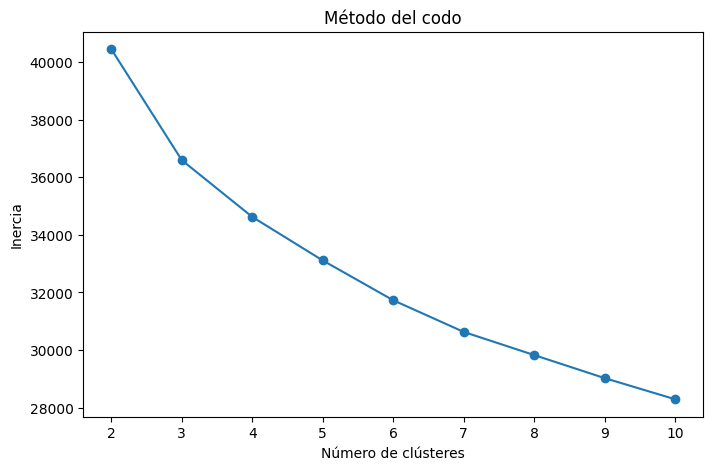

In [15]:
#Calculo de la inercia

inercias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=10,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inercias, marker='o')

plt.title('Método del codo')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia')
plt.xticks(range(2, 11))

plt.show()

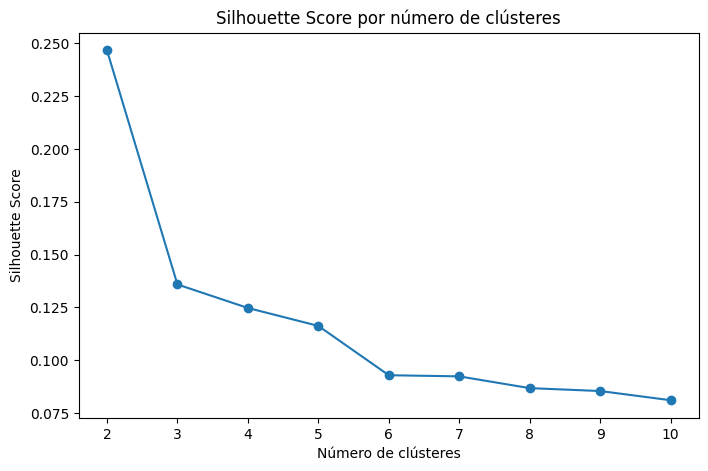

In [16]:
from sklearn.metrics import silhouette_score

silhouettes = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=10,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8,5))

plt.plot(range(2, 11), silhouettes, marker='o')

plt.title('Silhouette Score por número de clústeres')
plt.xlabel('Número de clústeres')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))

plt.show()

### Determinación del número óptimo de clústeres

Una de las decisiones más relevantes en la aplicación del algoritmo K-Means consiste en determinar el número adecuado de clústeres ((k)). Para ello, se emplearon dos criterios complementarios: el método del codo (*elbow method*) y el coeficiente de silueta (*silhouette score*).

El método del codo permitió observar la evolución de la inercia a medida que aumentaba el número de clústeres. Aunque la reducción de la inercia fue progresiva para todos los valores analizados, el cambio más acusado se produjo al pasar de dos a tres clústeres, estabilizándose posteriormente la pendiente de la curva.

Por su parte, el coeficiente de silueta alcanzó su valor máximo para (k = 2), obteniendo una puntuación de 0,247. Aunque este valor indica una separación moderada entre grupos, fue claramente superior a la obtenida para cualquier otra alternativa considerada, lo que sugiere que la estructura más natural presente en los datos corresponde a la existencia de dos grandes agrupaciones.

Dado que el coeficiente de silueta constituye una medida específica de la calidad de la partición obtenida, se decidió priorizar este criterio frente al método del codo para la selección del número definitivo de clústeres. En consecuencia, el análisis posterior se desarrolló considerando una solución de dos grupos.

Resulta especialmente interesante señalar que esta estructura dicotómica emerge de manera no supervisada, es decir, sin incorporar la variable objetivo utilizada en los modelos de clasificación. Este hallazgo aporta evidencia adicional sobre la posible existencia de dos perfiles diferenciados de bienestar subjetivo dentro de la población estudiada.

No obstante, debe señalarse que el valor absoluto del coeficiente de silueta obtenido refleja una separación moderada entre los grupos, lo que resulta coherente con la naturaleza compleja y multidimensional del bienestar subjetivo. En este sentido, es razonable esperar que existan zonas de transición y solapamiento entre perfiles, más que agrupaciones completamente diferenciadas.


In [18]:
# Creo el modelo K-Means
kmeans = KMeans(
    n_clusters=2,
    random_state=10,
    n_init=10
)

# Ajusto el modelo y obtengo las etiquetas
df_mod_cluster['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

In [24]:
df_mod_cluster['Cluster'].value_counts()


Cluster
0    3608
1    1676
Name: count, dtype: int64

In [25]:
df_mod_cluster['Cluster'].value_counts(normalize=True) * 100

Cluster
0    68.281605
1    31.718395
Name: proportion, dtype: float64

In [26]:
df_mod_cluster.groupby('Cluster')[variables_cluster].mean().round(2)

,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
Cluster,,,,,,,,,,
0,8.43,8.28,7.71,6.89,8.31,7.63,7.86,3.11,6.97,4.92
1,6.42,6.22,5.45,5.39,6.11,5.38,6.18,2.51,5.35,3.59


In [27]:
df_mod_cluster.groupby('Cluster')[
    ['Target_Satisfacc_Vida', 'Bienestar_alto']
].mean().round(2)

,Target_Satisfacc_Vida,Bienestar_alto
Cluster,,
0,8.00,0.72
1,5.84,0.15


La aplicación del algoritmo K-Means permitió identificar dos perfiles claramente diferenciados dentro de la población analizada. El primer clúster agrupó a individuos con mayores niveles de satisfacción en prácticamente todas las dimensiones consideradas, presentando una satisfacción media con la vida de 8,00 puntos y una proporción de bienestar alto del 72%. Por el contrario, el segundo clúster se caracterizó por niveles inferiores de satisfacción relacional, económica, emocional y de salud, registrando una satisfacción media con la vida de 5,84 puntos y una proporción de bienestar alto del 15%.

Resulta especialmente relevante que esta segmentación emergiera de manera completamente no supervisada, sin incorporar la variable objetivo utilizada en los modelos de clasificación. Este hallazgo aporta evidencia adicional sobre la existencia de dos grandes perfiles de bienestar subjetivo en la población estudiada y refuerza la coherencia de los resultados obtenidos a lo largo del proyecto mediante diferentes aproximaciones analíticas.

Se puede afirmar que el modelo ha sido capaz de descubrir perfiles de bienestar latentes en los datos

In [28]:
#Vamos a analizar algunas características demográficas de cada cluster:
variables_demo = [
    'Terr_hist',
    'Sexo',
    'Edad_interv',
    'Lugar_nacim',
    'Nacionalidad',
    'Nivel_estudios',
    'Actividad',
    'Tipo_hogar'
]

In [ ]:
def tabla_satisfaccion(variable):

    # Media de satisfacción por categoría y cluster
    tabla = pd.pivot_table(
        df_mod_cluster,
        values='Target_Satisfacc_Vida',
        index=variable,
        columns='Cluster',
        aggfunc='mean'
    )

    # Renombrar clusters
    tabla.columns = [
        'Alto nivel de bienestar',
        'Bajo nivel de bienestar'
    ]

    # Media para el total de la población
    tabla['Total población'] = (
        df_mod_cluster
        .groupby(variable)['Target_Satisfacc_Vida']
        .mean()
    )

    # Renombrar categorías de Sexo
    if variable == 'Sexo':
        tabla.index = tabla.index.map({
            1: 'Hombre',
            6: 'Mujer'
        })
        
    # Renombrar categorías de Terr Hist
    if variable == 'Terr_hist':
        tabla.index = tabla.index.map({
            1: 'Araba',
            20: 'Gipuzkoa',
            48: 'Bizkaia'
        })

    # Renombrar categorías de Actividad
    if variable == 'Actividad':
        tabla.index = tabla.index.map({
            1: 'Ocupados',
            2: 'Parados',
            3: 'Inactivos'
        })
    # Renombrar categorías de Nacionalidad
    if variable == 'Nacionalidad':
        tabla.index = tabla.index.map({
            1: 'Nacional',
            6: 'Extranjera'
        })
        
    # Renombrar categorías de Edad
    if variable == 'Edad_interv':
        tabla.index = tabla.index.map({
            1: '16 a 24',
            2: '25 a 34',
            3: '35 a 44',
            4: '45 a 54',
            5: '55 a 64',
            6: '65 a 75',
            7: '>75'
        })

    # Añadir fila resumen
    tabla.loc['Total población'] = [
        df_mod_cluster.loc[
            df_mod_cluster['Cluster'] == 0,
            'Target_Satisfacc_Vida'
        ].mean(),

        df_mod_cluster.loc[
            df_mod_cluster['Cluster'] == 1,
            'Target_Satisfacc_Vida'
        ].mean(),

        df_mod_cluster['Target_Satisfacc_Vida'].mean()
    ]

    return tabla.round(2)

In [ ]:
tabla_satisfaccion('Sexo')

,Alto nivel de bienestar,Bajo nivel de bienestar,Total población
Sexo,,,
Hombre,8.0,5.87,7.35
Mujer,8.0,5.82,7.28
Total población,8.0,5.84,7.31


In [37]:
tabla_satisfaccion('Terr_hist')

,Alto nivel de bienestar,Bajo nivel de bienestar,Total población
Terr_hist,,,
Araba,8.00,5.96,7.35
Gipuzkoa,8.03,5.77,7.34
Bizkaia,7.97,5.83,7.27
Total población,8.00,5.84,7.31


In [40]:
tabla_satisfaccion('Edad_interv')

,Alto nivel de bienestar,Bajo nivel de bienestar,Total población
Edad_interv,,,
16 a 24,8.23,6.40,7.83
25 a 34,7.99,5.99,7.42
35 a 44,8.18,6.04,7.44
45 a 54,7.99,6.03,7.21
55 a 64,7.91,5.93,7.21
65 a 75,7.96,5.81,7.45
>75,7.93,5.23,7.09
Total población,8.00,5.84,7.31


In [42]:
tabla_satisfaccion('Actividad')

,Alto nivel de bienestar,Bajo nivel de bienestar,Total población
Actividad,,,
Ocupados,8.05,6.23,7.47
Parados,7.91,5.51,6.70
Inactivos,7.95,5.49,7.22
Total población,8.00,5.84,7.31


In [43]:
tabla_satisfaccion('Nacionalidad')

,Alto nivel de bienestar,Bajo nivel de bienestar,Total población
Nacionalidad,,,
Nacional,7.98,5.85,7.31
Extranjera,8.29,5.78,7.38
Total población,8.00,5.84,7.31
